In [6]:
from pathlib import Path

from src.models.isolation_forest import IsolationForestModel
from src.models.local_outlier_factor import LocalOutlierFactorModel
from src.models.one_class_svm import OneClassSVMModel

In [7]:
from pathlib import Path

MODEL_DIR = Path("trained_models")

In [8]:
isolation_forest = IsolationForestModel.load(
    MODEL_DIR / "isolation_forest.joblib"
)

local_outlier_factor = LocalOutlierFactorModel.load(
    MODEL_DIR / "local_outlier_factor.joblib"
)

one_class_svm = OneClassSVMModel.load(
    MODEL_DIR / "one_class_svm.joblib"
)

print("✅ Models loaded successfully.")

2026-08-08 13:15:00 | INFO     | src.models.isolation_forest | Isolation Forest loaded <- trained_models/isolation_forest.joblib
2026-08-08 13:15:00 | INFO     | src.models.local_outlier_factor | Local Outlier Factor loaded <- trained_models/local_outlier_factor.joblib
2026-08-08 13:15:00 | INFO     | src.models.one_class_svm | One-Class SVM loaded <- trained_models/one_class_svm.joblib


✅ Models loaded successfully.


In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from src.evaluation.metrics import MetricsEvaluator
from src.evaluation.benchmark import ModelBenchmark
from src.evaluation.visualization import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_anomaly_score_distribution,
    plot_training_time,
    plot_inference_time,
    plot_model_comparison,
)

In [10]:
from src.preprocessing.loader import DataLoader

loader = DataLoader()

files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv", 
]

df = loader.load_multiple(files)

print(df.shape)

2026-08-08 13:15:05 | INFO     | AdaptiveRL | Loading Monday-WorkingHours.pcap_ISCX.csv started.
2026-08-08 13:15:05 | INFO     | AdaptiveRL | Reading /home/kalpe/projects/adaptive_rl_anomaly_detection/datasets/raw/Monday-WorkingHours.pcap_ISCX.csv
2026-08-08 13:15:08 | INFO     | AdaptiveRL | Loaded Monday-WorkingHours.pcap_ISCX.csv | Shape=(529918, 79)
2026-08-08 13:15:08 | INFO     | AdaptiveRL | Loading Monday-WorkingHours.pcap_ISCX.csv completed in 2.7486 seconds.
2026-08-08 13:15:08 | INFO     | AdaptiveRL | Loading Tuesday-WorkingHours.pcap_ISCX.csv started.
2026-08-08 13:15:08 | INFO     | AdaptiveRL | Reading /home/kalpe/projects/adaptive_rl_anomaly_detection/datasets/raw/Tuesday-WorkingHours.pcap_ISCX.csv
2026-08-08 13:15:10 | INFO     | AdaptiveRL | Loaded Tuesday-WorkingHours.pcap_ISCX.csv | Shape=(445909, 79)
2026-08-08 13:15:10 | INFO     | AdaptiveRL | Loading Tuesday-WorkingHours.pcap_ISCX.csv completed in 1.9182 seconds.
2026-08-08 13:15:10 | INFO     | AdaptiveRL | Lo

(2830743, 79)


In [11]:
from src.preprocessing.cleaner import DataCleaner

cleaner = DataCleaner()

df = cleaner.clean(df)

print(df.shape)

2026-08-08 13:15:31 | INFO     | AdaptiveRL | Replacing Infinite Values started.
2026-08-08 13:15:35 | INFO     | AdaptiveRL | Replacing Infinite Values completed in 3.2032 seconds.
2026-08-08 13:15:35 | INFO     | AdaptiveRL | Removing Duplicates started.
2026-08-08 13:15:46 | INFO     | AdaptiveRL | Removed 308381 duplicate rows.
2026-08-08 13:15:46 | INFO     | AdaptiveRL | Removing Duplicates completed in 11.7091 seconds.
2026-08-08 13:15:46 | INFO     | AdaptiveRL | Removing Missing Values started.
2026-08-08 13:15:47 | INFO     | AdaptiveRL | Removed 1564 rows containing missing values.
2026-08-08 13:15:47 | INFO     | AdaptiveRL | Removing Missing Values completed in 0.8465 seconds.
2026-08-08 13:15:47 | INFO     | AdaptiveRL | Removing Constant Columns started.
2026-08-08 13:15:49 | INFO     | AdaptiveRL | Removed 8 constant columns.
2026-08-08 13:15:49 | INFO     | AdaptiveRL | Removing Constant Columns completed in 2.1689 seconds.
2026-08-08 13:15:49 | INFO     | AdaptiveRL |

(2520798, 71)


In [12]:
df.columns = df.columns.str.strip()

In [13]:
from src.preprocessing.encoder import DataEncoder

encoder = DataEncoder(target_column=" Label")

df = encoder.fit_transform(df)

print(df.dtypes["Label"])
print(df["Label"].unique()[:10])

2026-08-08 13:15:58 | INFO     | AdaptiveRL | Encoding Dataset started.
2026-08-08 13:15:58 | INFO     | AdaptiveRL | Encoding Dataset completed in 0.3131 seconds.
2026-08-08 13:15:58 | INFO     | AdaptiveRL | Encoding completed.


int64
[ 0  7 11  6  5  4  3  8 12 14]


In [14]:
from src.preprocessing.scaler import DataScaler

scaler = DataScaler(
    method="standard",
    target_column="Label",
)

df = scaler.fit_transform(df)

print(df.shape)
print(df["Label"].dtype)
print(df["Label"].unique()[:10])

2026-08-08 13:16:02 | INFO     | AdaptiveRL | Scaler (standard) fitted on 70 feature columns.
2026-08-08 13:16:03 | INFO     | AdaptiveRL | Scaling Dataset started.
2026-08-08 13:16:06 | INFO     | AdaptiveRL | Scaling Dataset completed in 2.1110 seconds.
2026-08-08 13:16:06 | INFO     | AdaptiveRL | Scaling completed.


(2520798, 71)
int64
[ 0  7 11  6  5  4  3  8 12 14]


In [19]:
X = df.drop(columns=["Label"])
y = df["Label"]

print(f"Features shape : {X.shape}")
print(f"Labels shape   : {y.shape}")
print("\nLabel Distribution:")
print(y.value_counts().sort_index())

Features shape : (2520798, 70)
Labels shape   : (2520798,)

Label Distribution:
Label
0     2095057
1        1948
2      128014
3       10286
4      172846
5        5228
6        5385
7        5931
8          11
9          36
10      90694
11       3219
12       1470
13         21
14        652
Name: count, dtype: int64


In [20]:
y = (y != 0).astype(int)

print(y.value_counts())

Label
0    2095057
1     425741
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Train Shape : {X_train.shape}")
print(f"Test Shape  : {X_test.shape}")

Train Shape : (2016638, 70)
Test Shape  : (504160, 70)


In [22]:
from src.evaluation.metrics import MetricsEvaluator
from src.evaluation.benchmark import ModelBenchmark

evaluator = MetricsEvaluator()
benchmark = ModelBenchmark()

In [23]:
if_predictions = isolation_forest.predict(X_test)

if_scores = isolation_forest.anomaly_score(X_test)

if_result = evaluator.evaluate(
    y_true=y_test,
    y_pred=if_predictions,
    anomaly_scores=if_scores,
    model_name="Isolation Forest",
)

print(if_result.summary())

Evaluation Summary: Isolation Forest
Samples          : 504160 (Normal: 419012, Anomaly: 85148)
------------------------------------------------------------
Accuracy         : 0.8154
Precision        : 0.3438
Recall           : 0.1025
F1 Score         : 0.1579
ROC-AUC          : 0.7499
PR-AUC           : 0.3399
------------------------------------------------------------
True Positive Rate  (TPR) : 0.1025
True Negative Rate  (TNR) : 0.9603
False Positive Rate (FPR) : 0.0397
False Negative Rate (FNR) : 0.8975
------------------------------------------------------------
Confusion Matrix:
    TN: 402359   FP: 16653   
    FN: 76422    TP: 8726    


In [24]:
lof_predictions = local_outlier_factor.predict(X_test)

lof_scores = local_outlier_factor.anomaly_score(X_test)

lof_result = evaluator.evaluate(
    y_true=y_test,
    y_pred=lof_predictions,
    anomaly_scores=lof_scores,
    model_name="Local Outlier Factor",
)

print(lof_result.summary())

Evaluation Summary: Local Outlier Factor
Samples          : 504160 (Normal: 419012, Anomaly: 85148)
------------------------------------------------------------
Accuracy         : 0.7905
Precision        : 0.1010
Recall           : 0.0304
F1 Score         : 0.0467
ROC-AUC          : 0.4587
PR-AUC           : 0.1507
------------------------------------------------------------
True Positive Rate  (TPR) : 0.0304
True Negative Rate  (TNR) : 0.9450
False Positive Rate (FPR) : 0.0550
False Negative Rate (FNR) : 0.9696
------------------------------------------------------------
Confusion Matrix:
    TN: 395971   FP: 23041   
    FN: 82560    TP: 2588    


In [25]:
svm_predictions = one_class_svm.predict(X_test)

svm_scores = one_class_svm.anomaly_score(X_test)

svm_result = evaluator.evaluate(
    y_true=y_test,
    y_pred=svm_predictions,
    anomaly_scores=svm_scores,
    model_name="One-Class SVM",
)

print(svm_result.summary())

Evaluation Summary: One-Class SVM
Samples          : 504160 (Normal: 419012, Anomaly: 85148)
------------------------------------------------------------
Accuracy         : 0.8071
Precision        : 0.2608
Recall           : 0.0776
F1 Score         : 0.1196
ROC-AUC          : 0.7221
PR-AUC           : 0.3049
------------------------------------------------------------
True Positive Rate  (TPR) : 0.0776
True Negative Rate  (TNR) : 0.9553
False Positive Rate (FPR) : 0.0447
False Negative Rate (FNR) : 0.9224
------------------------------------------------------------
Confusion Matrix:
    TN: 400291   FP: 18721   
    FN: 78543    TP: 6605    


In [26]:
comparison_df = evaluator.compare(
    [
        if_result,
        lof_result,
        svm_result,
    ]
)

comparison_df

,model_name,accuracy,precision,recall,f1,roc_auc,pr_auc,true_positive_rate,true_negative_rate,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives,n_samples,n_anomalies,n_normal,notes
0,Isolation Forest,0.815386,0.343828,0.102480,0.157898,0.749923,0.339947,0.102480,0.960257,0.039743,0.897520,402359,16653,76422,8726,504160,85148,419012,
1,Local Outlier Factor,0.790541,0.100979,0.030394,0.046725,0.458718,0.150706,0.030394,0.945011,0.054989,0.969606,395971,23041,82560,2588,504160,85148,419012,
2,One-Class SVM,0.807077,0.260799,0.077571,0.119576,0.722146,0.304867,0.077571,0.955321,0.044679,0.922429,400291,18721,78543,6605,504160,85148,419012,


In [27]:
import time
import pandas as pd

benchmark_results = []

models = {
    "Isolation Forest": isolation_forest,
    "Local Outlier Factor": local_outlier_factor,
    "One-Class SVM": one_class_svm,
}

for name, model in models.items():

    start = time.perf_counter()
    _ = model.predict(X_test)
    prediction_time = time.perf_counter() - start

    start = time.perf_counter()
    _ = model.anomaly_score(X_test)
    scoring_time = time.perf_counter() - start

    benchmark_results.append(
        {
            "model_name": name,
            "prediction_time_seconds": prediction_time,
            "scoring_time_seconds": scoring_time,
        }
    )

benchmark_df = pd.DataFrame(benchmark_results)

benchmark_df

,model_name,prediction_time_seconds,scoring_time_seconds
0,Isolation Forest,3.450430,3.550077
1,Local Outlier Factor,33.253419,37.121474
2,One-Class SVM,71.715006,71.512330


/tmp/ipykernel_1453/2788332385.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


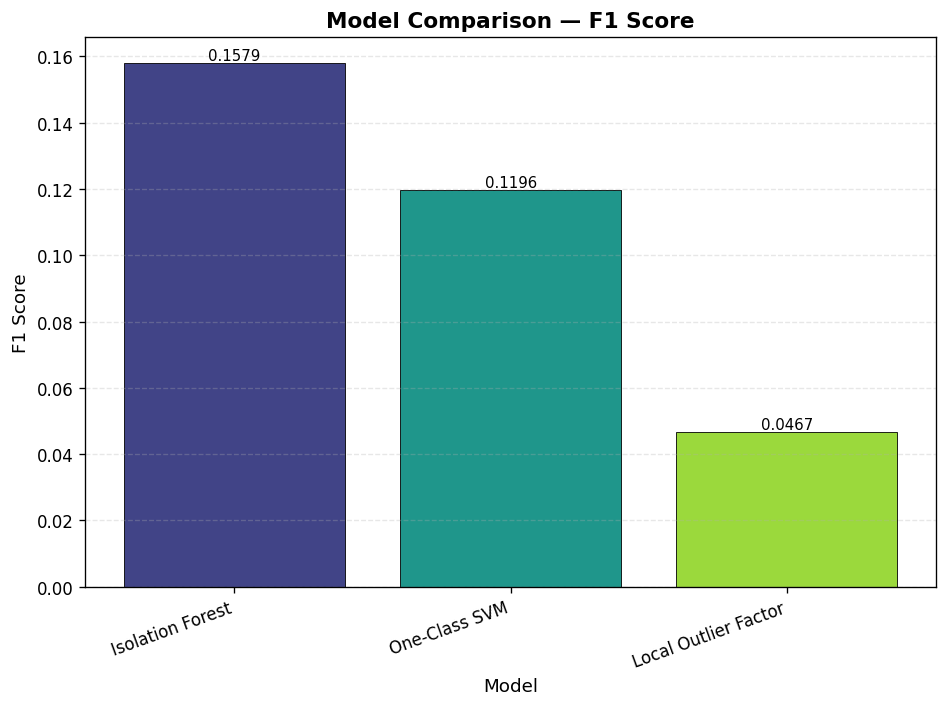

In [28]:
from src.evaluation.visualization import plot_model_comparison

fig = plot_model_comparison(
    comparison_df["model_name"],
    comparison_df["f1"],
    metric_name="F1 Score",
)

fig.show()

/tmp/ipykernel_1453/2343067985.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


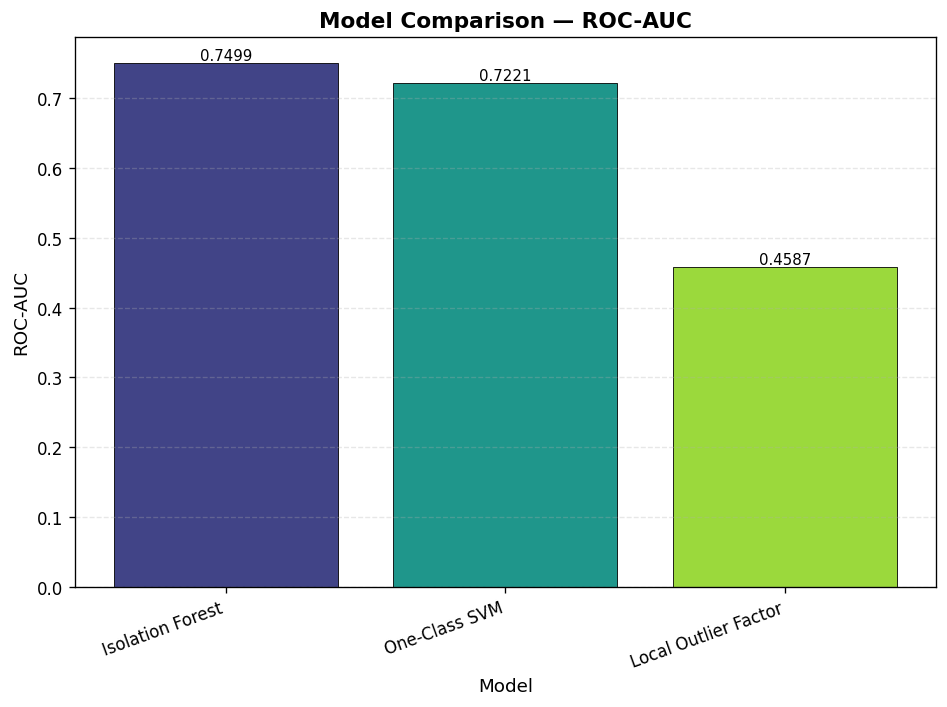

In [29]:
fig = plot_model_comparison(
    comparison_df["model_name"],
    comparison_df["roc_auc"],
    metric_name="ROC-AUC",
)

fig.show()

/tmp/ipykernel_1453/2242271325.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


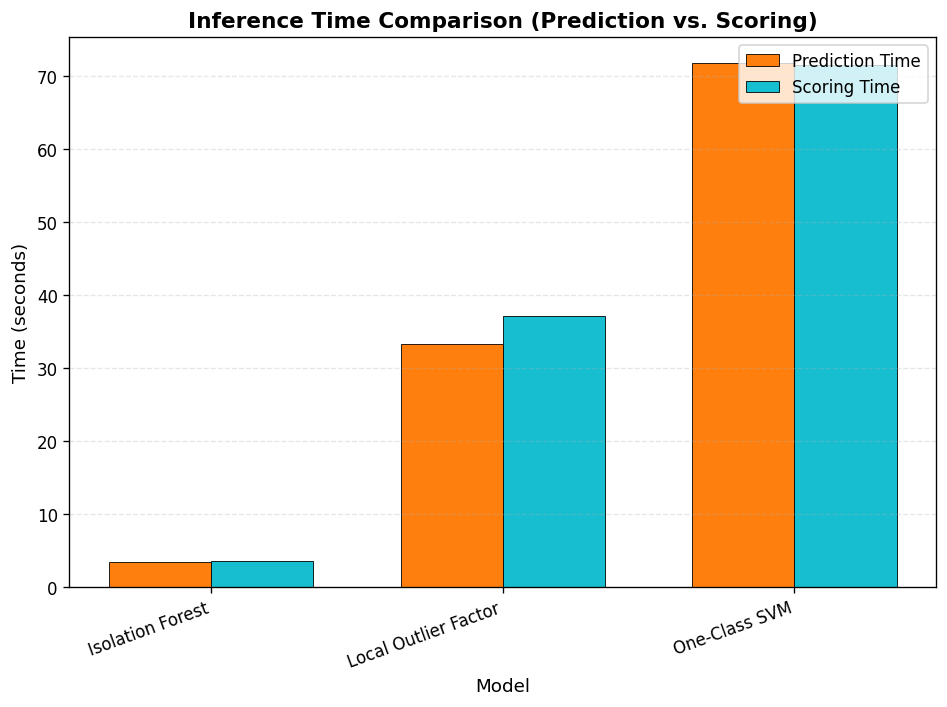

In [30]:
from src.evaluation.visualization import plot_inference_time

fig = plot_inference_time(
    benchmark_df["model_name"],
    benchmark_df["prediction_time_seconds"],
    benchmark_df["scoring_time_seconds"],
)

fig.show()

/tmp/ipykernel_1453/2271125296.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


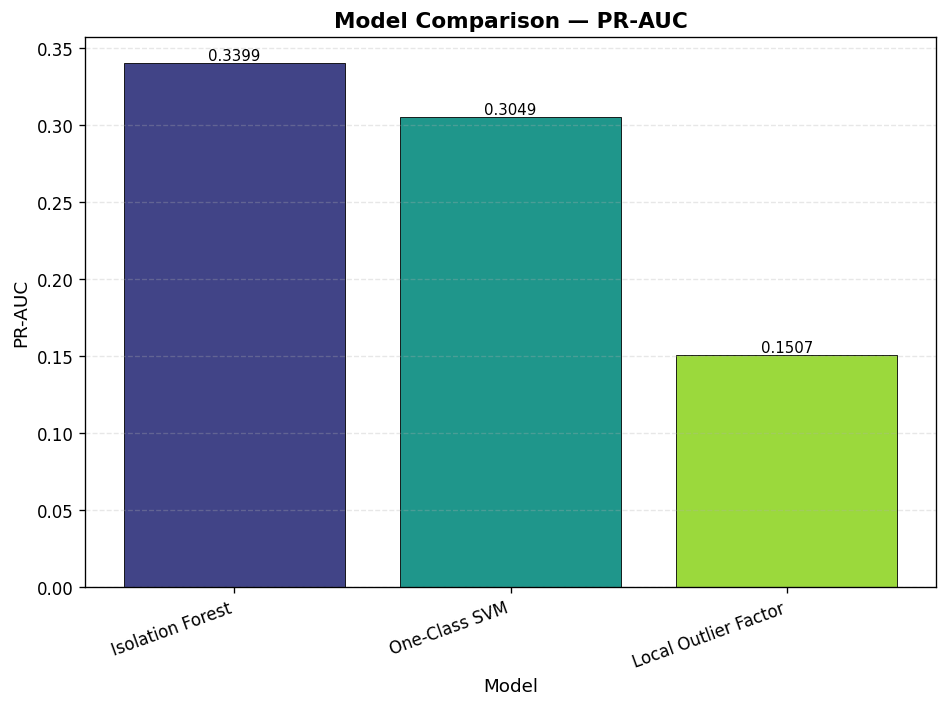

In [31]:
fig = plot_model_comparison(
    comparison_df["model_name"],
    comparison_df["pr_auc"],
    metric_name="PR-AUC",
)

fig.show()

/tmp/ipykernel_1453/1762182062.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


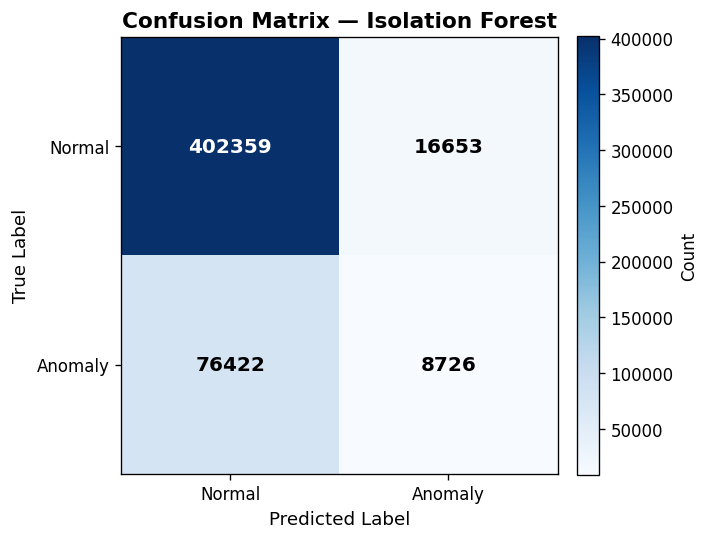

In [32]:
from src.evaluation.visualization import plot_confusion_matrix

fig = plot_confusion_matrix(
    if_result.confusion_matrix,
    model_name="Isolation Forest",
)

fig.show()

/tmp/ipykernel_1453/558340266.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


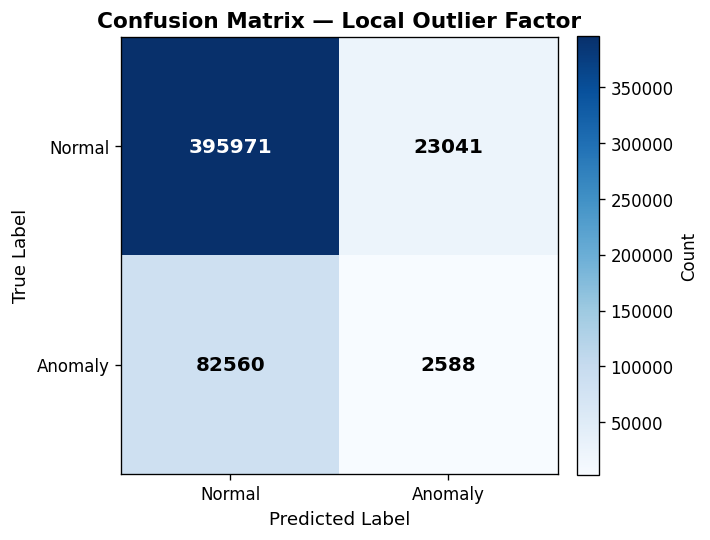

In [33]:
fig = plot_confusion_matrix(
    lof_result.confusion_matrix,
    model_name="Local Outlier Factor",
)

fig.show()

/tmp/ipykernel_1453/3349875712.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


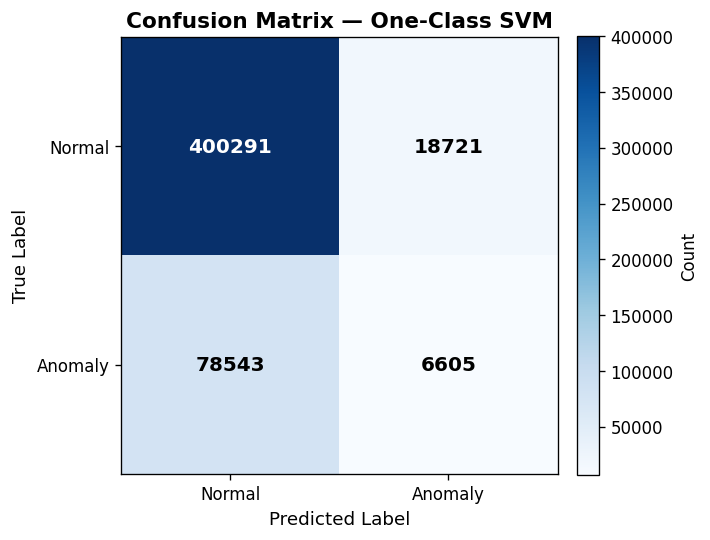

In [34]:
fig = plot_confusion_matrix(
    svm_result.confusion_matrix,
    model_name="One-Class SVM",
)

fig.show()

In [35]:
import numpy as np

print("Prediction arrays:")
print("IF vs LOF:", np.array_equal(if_predictions, lof_predictions))
print("IF vs SVM:", np.array_equal(if_predictions, svm_predictions))
print("LOF vs SVM:", np.array_equal(lof_predictions, svm_predictions))

print("\nScore arrays:")
print("IF vs LOF:", np.array_equal(if_scores, lof_scores))
print("IF vs SVM:", np.array_equal(if_scores, svm_scores))
print("LOF vs SVM:", np.array_equal(lof_scores, svm_scores))

print("\nConfusion matrices:")
print("IF:\n", if_result.confusion_matrix)
print("LOF:\n", lof_result.confusion_matrix)
print("SVM:\n", svm_result.confusion_matrix)

Prediction arrays:
IF vs LOF: False
IF vs SVM: False
LOF vs SVM: False

Score arrays:
IF vs LOF: False
IF vs SVM: False
LOF vs SVM: False

Confusion matrices:
IF:
 [[402359  16653]
 [ 76422   8726]]
LOF:
 [[395971  23041]
 [ 82560   2588]]
SVM:
 [[400291  18721]
 [ 78543   6605]]


/tmp/ipykernel_1453/2197826152.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


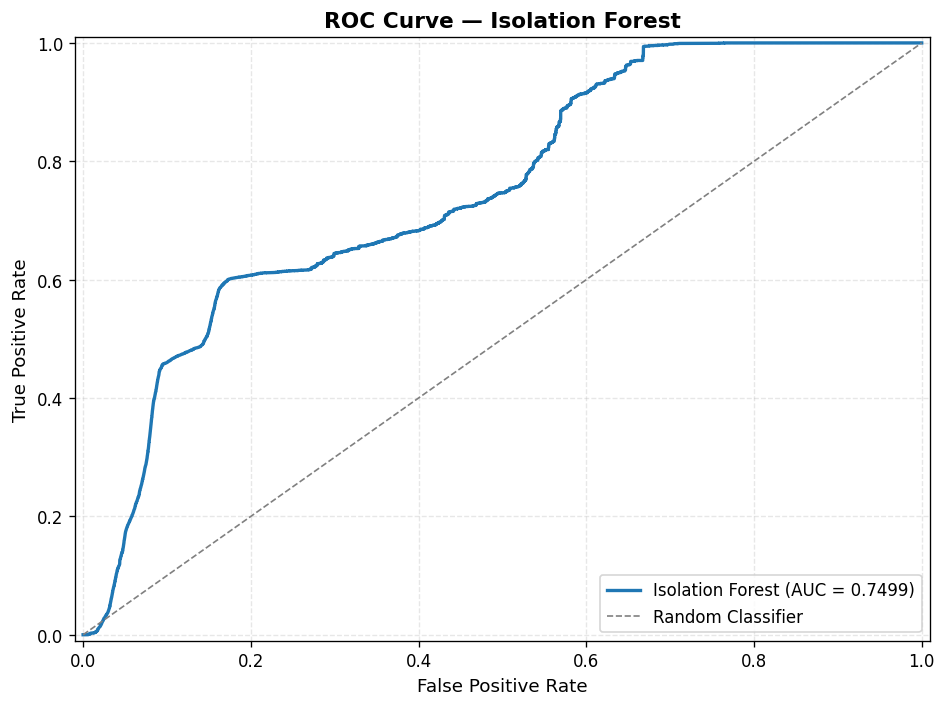

In [36]:
from src.evaluation.visualization import plot_roc_curve

fig = plot_roc_curve(
    y_test,
    if_scores,
    model_name="Isolation Forest",
)

fig.show()

/tmp/ipykernel_1453/3612833055.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


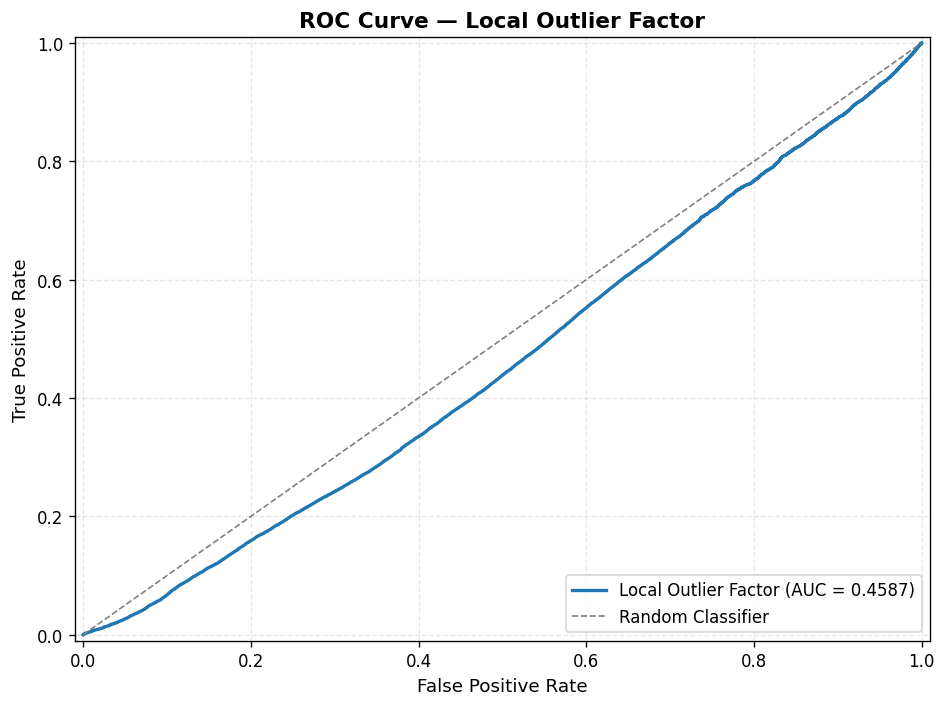

In [37]:
fig = plot_roc_curve(
    y_test,
    lof_scores,
    model_name="Local Outlier Factor",
)

fig.show()

/tmp/ipykernel_1453/4233448514.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


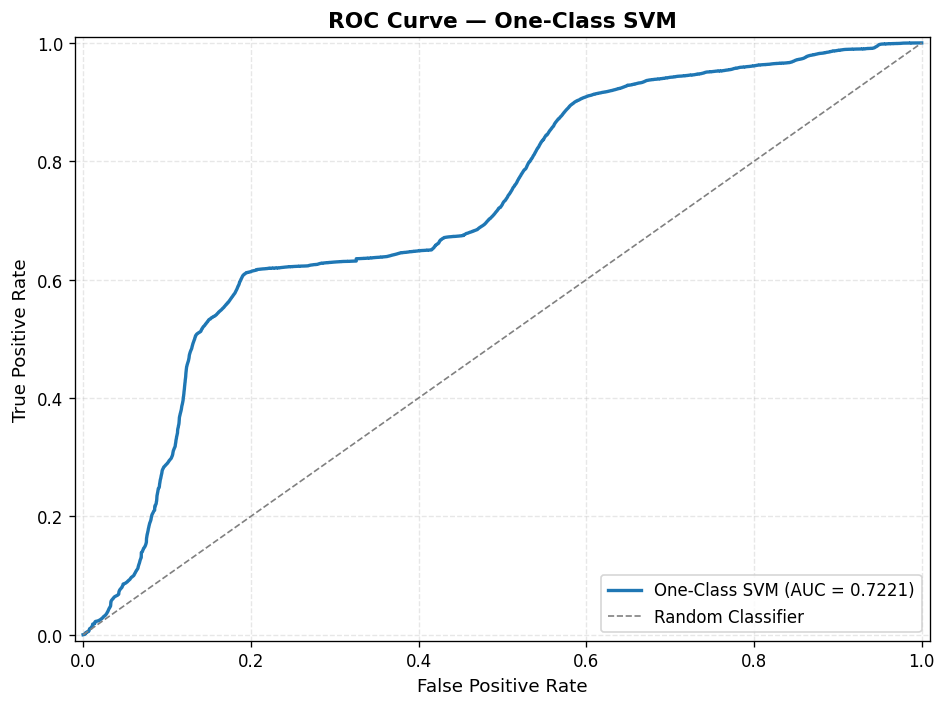

In [38]:
fig = plot_roc_curve(
    y_test,
    svm_scores,
    model_name="One-Class SVM",
)

fig.show()

/tmp/ipykernel_1453/3411437969.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


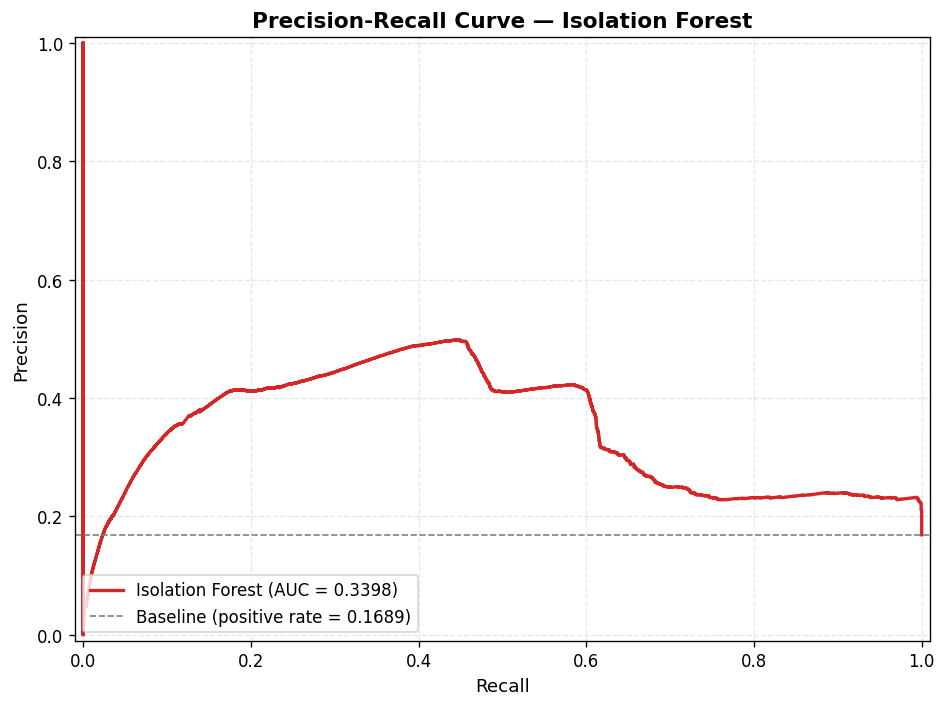

In [39]:
from src.evaluation.visualization import plot_precision_recall_curve

fig = plot_precision_recall_curve(
    y_test,
    if_scores,
    model_name="Isolation Forest",
)

fig.show()

/tmp/ipykernel_1453/3155631977.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


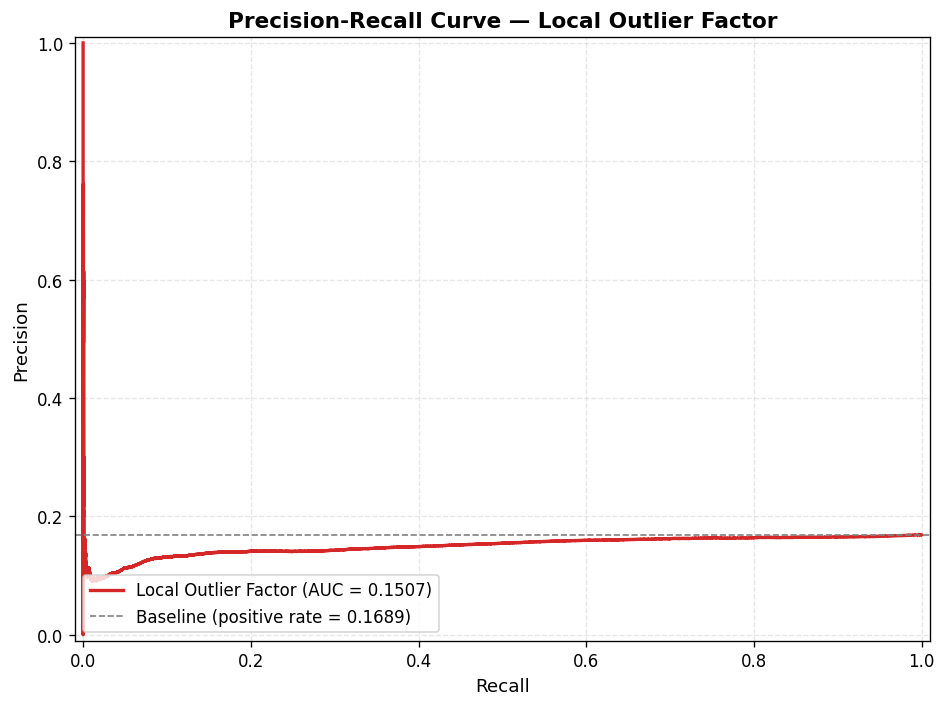

In [40]:
fig = plot_precision_recall_curve(
    y_test,
    lof_scores,
    model_name="Local Outlier Factor",
)

fig.show()

/tmp/ipykernel_1453/318727931.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


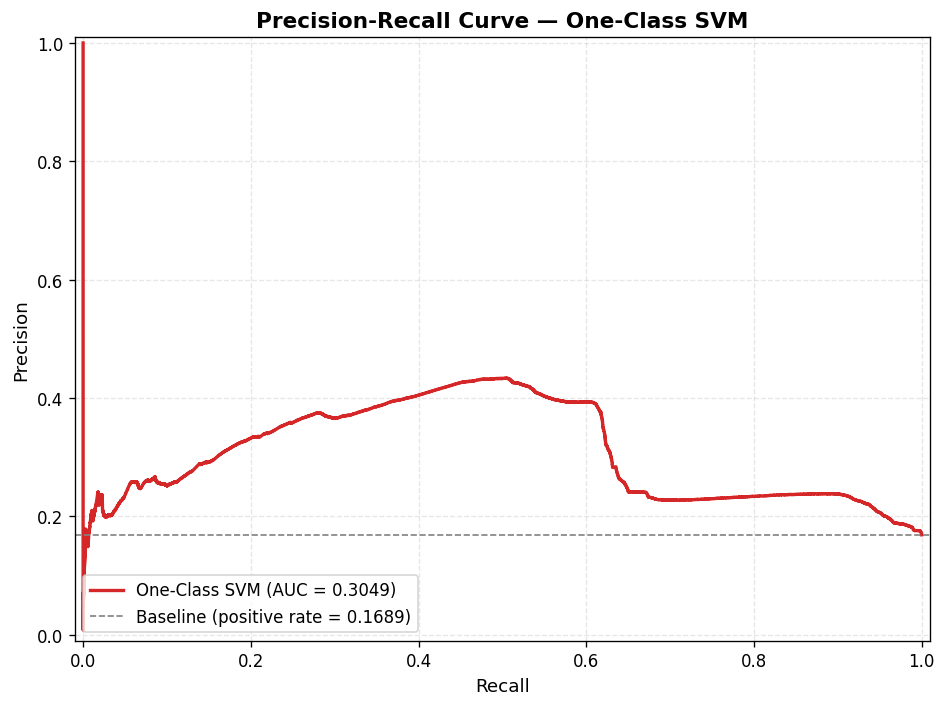

In [41]:
fig = plot_precision_recall_curve(
    y_test,
    svm_scores,
    model_name="One-Class SVM",
)

fig.show()

/tmp/ipykernel_1453/2561543718.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


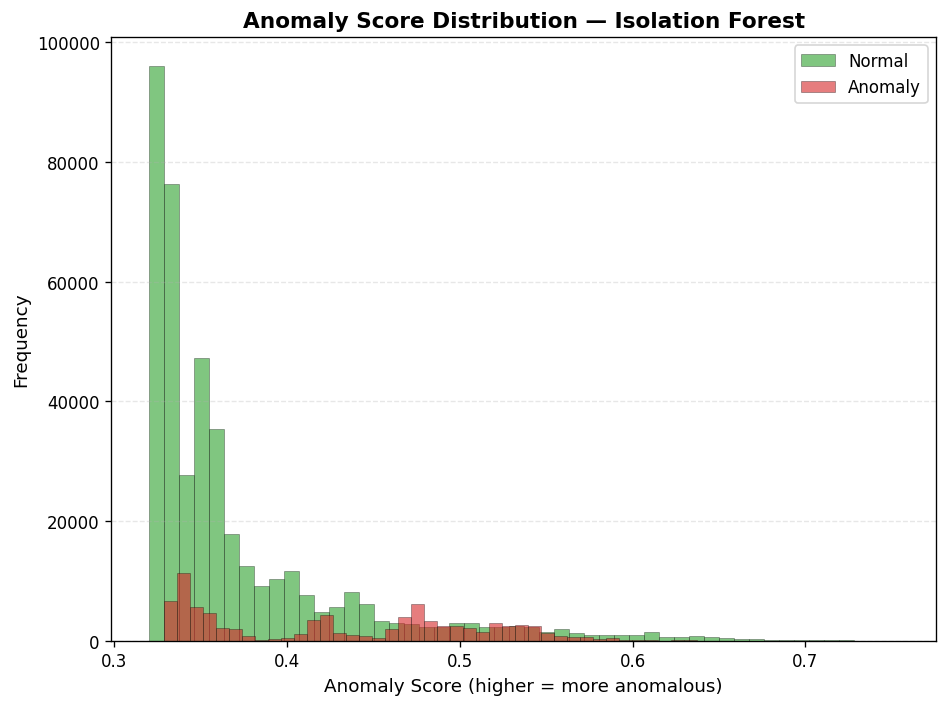

In [42]:
from src.evaluation.visualization import plot_anomaly_score_distribution

fig = plot_anomaly_score_distribution(
    if_scores,
    y_true=y_test,
    model_name="Isolation Forest",
)

fig.show()

/tmp/ipykernel_1453/2783238555.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


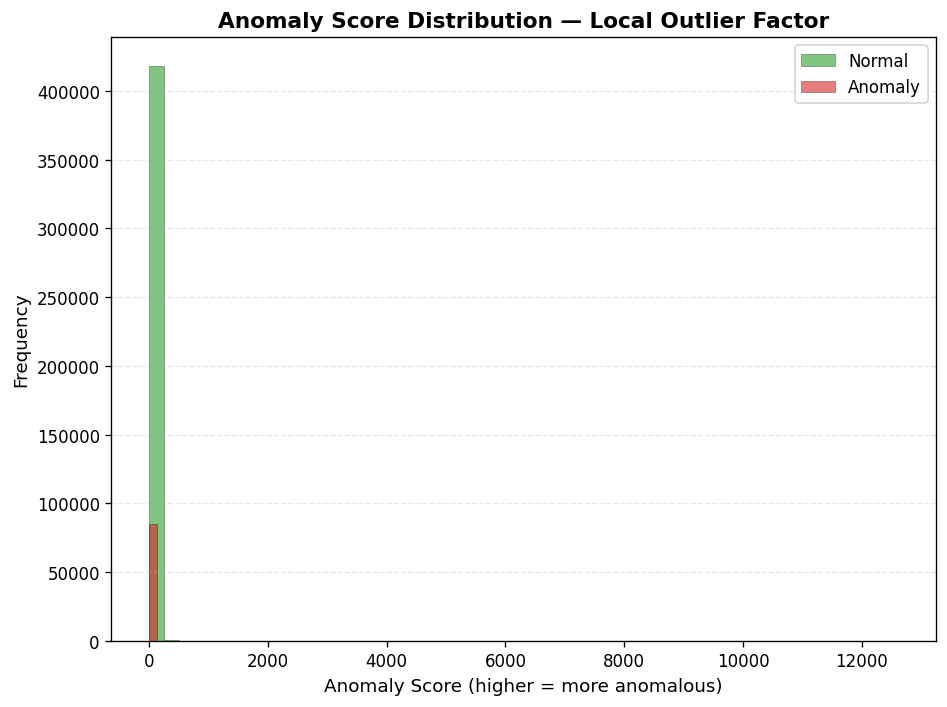

In [43]:
fig = plot_anomaly_score_distribution(
    lof_scores,
    y_true=y_test,
    model_name="Local Outlier Factor",
)

fig.show()

/tmp/ipykernel_1453/225452975.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


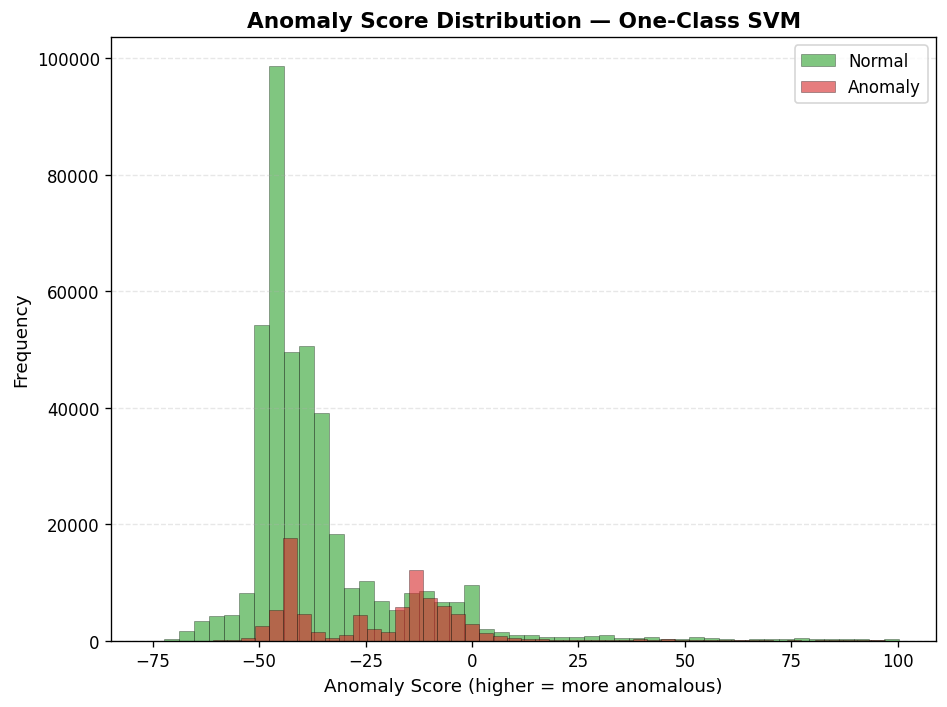

In [44]:
fig = plot_anomaly_score_distribution(
    svm_scores,
    y_true=y_test,
    model_name="One-Class SVM",
)

fig.show()

In [45]:
ranking = comparison_df.sort_values(
    by="f1",
    ascending=False,
).reset_index(drop=True)

display(ranking)

best_model = ranking.iloc[0]

print("=" * 60)
print("🏆 Best Performing Model")
print("=" * 60)
print(f"Model     : {best_model['model_name']}")
print(f"F1 Score  : {best_model['f1']:.4f}")
print(f"ROC-AUC   : {best_model['roc_auc']:.4f}")
print(f"PR-AUC    : {best_model['pr_auc']:.4f}")
print(f"Accuracy  : {best_model['accuracy']:.4f}")
print("=" * 60)

,model_name,accuracy,precision,recall,f1,roc_auc,pr_auc,true_positive_rate,true_negative_rate,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives,n_samples,n_anomalies,n_normal,notes
0,Isolation Forest,0.815386,0.343828,0.102480,0.157898,0.749923,0.339947,0.102480,0.960257,0.039743,0.897520,402359,16653,76422,8726,504160,85148,419012,
1,One-Class SVM,0.807077,0.260799,0.077571,0.119576,0.722146,0.304867,0.077571,0.955321,0.044679,0.922429,400291,18721,78543,6605,504160,85148,419012,
2,Local Outlier Factor,0.790541,0.100979,0.030394,0.046725,0.458718,0.150706,0.030394,0.945011,0.054989,0.969606,395971,23041,82560,2588,504160,85148,419012,


🏆 Best Performing Model
Model     : Isolation Forest
F1 Score  : 0.1579
ROC-AUC   : 0.7499
PR-AUC    : 0.3399
Accuracy  : 0.8154
